In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib import colors
from sklearn.datasets import make_blobs

from push_environment_v1_upd import PushEnvironment
from push_environment_gym_wrapper import PushEnvironmentGym
from preprocess_environment_v1 import PreprocessEnvironment

## Defining Parameters

In [2]:
# Define the environment types
RANDOM = 0
RECTANGLES = 1
SHOVEL_RECTANGLES_3 = 3
SHOVEL_RECTANGLES_2 = 2
ORIENTED_RECTANGLE = 4
BLOBS = 5
SHOVEL_RECTANGLES_1 = 6

# Environment = SHOVEL_RECTANGLES_1
Environment = ORIENTED_RECTANGLE

# Parameters
num_particles = 2000
bounding_box = np.array([[0, 0], [1, 1]])
shovel_width = 0.2 
# shovel_width = 0.24 
rect_length = 0.5 # Length of the shovel rectangle
particle_radius_world = 0.003
# np.random.seed(0)

if Environment == RANDOM:
    particles = np.random.uniform(low=bounding_box[0], high=bounding_box[1], size=(num_particles, 2))
elif Environment == RECTANGLES:
    particles = np.concatenate([
        np.random.uniform(low=[0.0, 0.0], high=[0.5, 0.25], size=(int(num_particles / 4), 2)),
        np.random.uniform(low=[0.5, 0.0], high=[1.0, 0.25], size=(int(num_particles / 4), 2)),
        np.random.uniform(low=[0.0, 0.75], high=[0.5, 1.0], size=(int(num_particles / 4), 2)),
        np.random.uniform(low=[0.5, 0.75], high=[1.0, 1.0], size=(int(num_particles / 4), 2))
    ])
elif Environment == BLOBS:
    centers = 8
    particles, _ = make_blobs(n_samples=num_particles, n_features=2, centers=centers, center_box=(0.1, 0.9), cluster_std=0.05, random_state=15)
    # Clip to stay in bounds
    # particles = np.clip(particles, 0, 1)
elif Environment == SHOVEL_RECTANGLES_1:
    particles = np.concatenate([
        np.random.uniform(low=[0.0 + particle_radius_world, 0.4 + particle_radius_world], high=[rect_length - particle_radius_world, 0.4 + shovel_width - particle_radius_world], size=(int(num_particles), 2)),
        # np.random.uniform(low=[0.0, 1.0 - (shovel_width)], high=[rect_length, 1.0], size=(int(num_particles / 2), 2))
    ])
    
elif Environment == SHOVEL_RECTANGLES_2:
    particles = np.concatenate([
        np.random.uniform(low=[0.0 + particle_radius_world, 0.0 + particle_radius_world], high=[rect_length - particle_radius_world, shovel_width - particle_radius_world], size=(int(num_particles / 2), 2)),
        np.random.uniform(low=[0.0 + particle_radius_world, 1.0 - (shovel_width - particle_radius_world)], high=[rect_length - particle_radius_world, 1.0 - particle_radius_world], size=(int(num_particles / 2), 2))
    ])
elif Environment == SHOVEL_RECTANGLES_3:
    particles = np.concatenate([
        np.random.uniform(low=[0.0 + particle_radius_world, 0.0 + particle_radius_world], high=[rect_length - particle_radius_world, shovel_width - particle_radius_world], size=(int(num_particles / 3), 2)),
        np.random.uniform(low=[1 - rect_length + particle_radius_world, 0.5 - shovel_width/2 + particle_radius_world], high=[1 - particle_radius_world, 0.5 + shovel_width/2 - particle_radius_world], size=(int(num_particles / 3), 2)),
        np.random.uniform(low=[0.0 + particle_radius_world, 1.0 - shovel_width + particle_radius_world], high=[rect_length - particle_radius_world, 1.0 - particle_radius_world], size=(int(num_particles / 3), 2))
    ])
elif Environment == ORIENTED_RECTANGLE:
    def generate_oriented_rect(center, length, width, angle_rad, n_particles):
        dir_vector = np.array([np.cos(angle_rad), np.sin(angle_rad)])
        perp_vector = np.array([-dir_vector[1], dir_vector[0]])
        t_vals = np.random.uniform(-length / 2, length / 2, n_particles)
        s_vals = np.random.uniform(-width / 2, width / 2, n_particles)
        return center + np.outer(t_vals, dir_vector) + np.outer(s_vals, perp_vector)

    rect1 = generate_oriented_rect(center=np.array([0.8, 0.15]), length=0.6, width=shovel_width/3, angle_rad=np.pi / 4, n_particles=num_particles // 2)
    # rect2 = generate_oriented_rect(center=np.array([0.6, 0.3]), length=0.3, width=shovel_width, angle_rad=-np.pi / 4, n_particles=num_particles // 2)
    # particles = np.concatenate([rect1, rect2])
    # particles = np.clip(rect1, 0, 1)  # Ensure all inside bounding box
    particles = rect1

In [3]:
grid_size = 20  # 20x20 grid
# grid_size = 25
boundary_points = [(0, y) for y in np.linspace(0, 1, grid_size, endpoint=False)] + \
                [(x, 1) for x in np.linspace(0, 1, grid_size, endpoint=False)] + \
                [(1, y) for y in np.linspace(1, 0, grid_size, endpoint=False)] + \
                [(x, 0) for x in np.linspace(1, 0, grid_size, endpoint=False)]

# delta_s_options = list(np.arange(-int(len(boundary_points)/4), int(len(boundary_points)/4)))
delta_s_options = list(np.arange(-int(len(boundary_points)/2), int(len(boundary_points)/2)))

theta_options = np.linspace(0, np.pi, 9)  
# theta_options = np.linspace(0, np.pi, 5)
# theta_options = np.linspace(0, np.pi, 3)

s0 = 0  # Start at the first boundary point
# max_pushes = 5  # Maximum number of pushes allowed
max_pushes = 3  # Maximum number of pushes allowed
coverage_threshold = 0.95  # Coverage threshold for stopping

stochasity = False
binary_grid = not stochasity


In [4]:
# delta_s_options = list(np.arange(-int(len(boundary_points)/2), int(len(boundary_points)/2), 2))
# delta_s_options = list(np.arange(-int(len(boundary_points)/2), int(len(boundary_points)/2), 4))
# delta_s_options = list(np.arange(-int(len(boundary_points)/2), int(len(boundary_points)/2)))
# delta_s_options = list(np.arange(-int(len(boundary_points)/4), int(len(boundary_points)/4), 2))
print(np.shape(delta_s_options))
print(delta_s_options)
print(np.shape(theta_options))
print(theta_options)


(80,)
[-40, -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
(9,)
[0.         0.39269908 0.78539816 1.17809725 1.57079633 1.96349541
 2.35619449 2.74889357 3.14159265]


In [4]:
preprocess = PreprocessEnvironment(    
    boundary_points=boundary_points,
    push_width=shovel_width,  
    stochasticity=stochasity,
    grid_size=grid_size,
    binary_grid=binary_grid
    )

binary_img = preprocess.particles_to_binary_img(particles, 1000, bounding_box, particle_radius_world)
print(binary_img.shape)

Deterministic push enabled.
Rasterizing 1000 particles (with size) onto a 1000x1000 binary grid...
Particle world radius 0.003 corresponds to a pixel 'radius' of 3
Rasterization complete.
(1000, 1000)


In [5]:
occ_grid, total_ooccupied = preprocess.binary_img_to_grid(binary_img)
total_pixels_in_cell = preprocess.total_pixels_in_cell

det_env = PushEnvironmentGym(
    boundary_points=boundary_points,
    delta_s_options=delta_s_options,
    theta_options=theta_options,
    push_width=shovel_width,  
    initial_pos=s0,        
    max_pushes=max_pushes,
    coverage_thresh=coverage_threshold,  
    occupancy_grid=occ_grid,
    total_occupied=total_ooccupied,
    grid_size=grid_size
)
stochastic_env = PushEnvironmentGym(
    boundary_points=boundary_points,
    delta_s_options=delta_s_options,
    theta_options=theta_options,
    push_width=shovel_width, 
    initial_pos=s0,          
    max_pushes=max_pushes,
    coverage_thresh=coverage_threshold,
    occupancy_grid=occ_grid,
    total_occupied=total_ooccupied,
    total_pixels_in_cell=total_pixels_in_cell,
    stochasticity=True,
    grid_size=grid_size
)

if stochasity:
    env = stochastic_env
else:    
    env = det_env

Deterministic push enabled.
Stochastic push enabled.


## Plot Environment

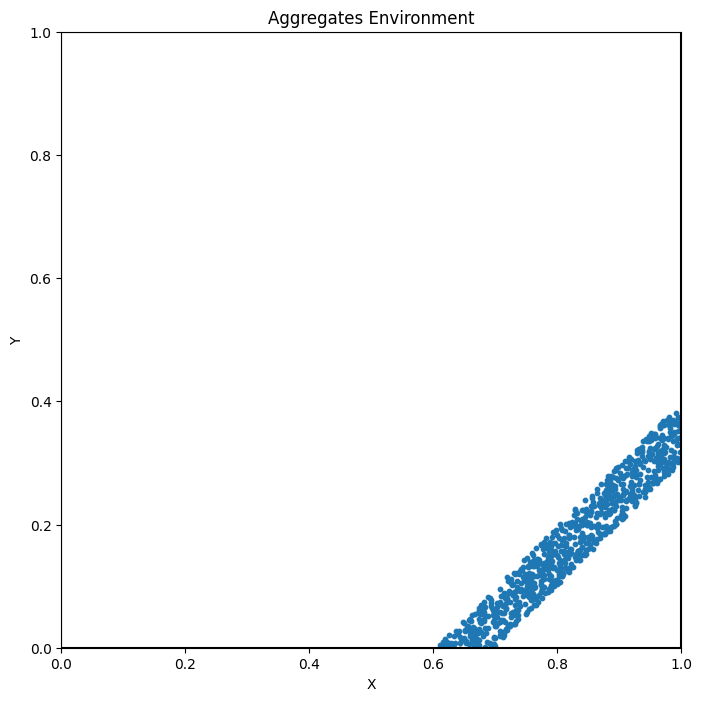

In [7]:
env.draw_environment(particles)
# stochastic_env.draw_environment(particles)

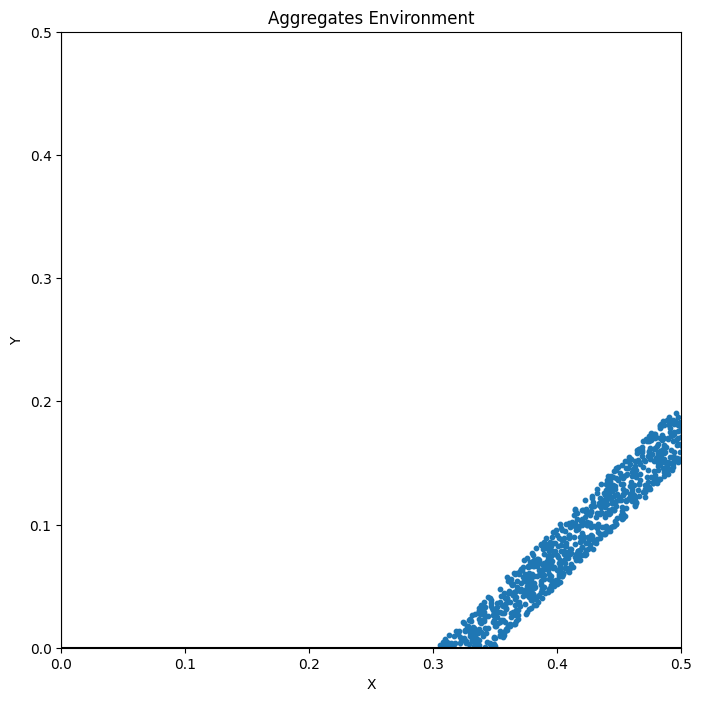

In [8]:
env.draw_real_environment(particles)
# stochastic_env.draw_real_environment(particles)

Text(0.5, 1.0, 'Binary Image')

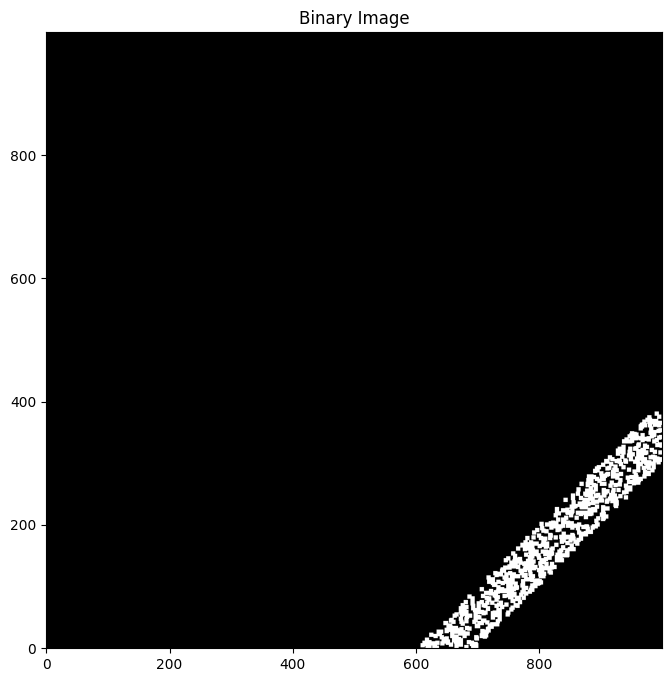

In [9]:
plt.figure(figsize=(8,8))
plt.imshow(binary_img, cmap='gray', origin='lower')
plt.title("Binary Image")

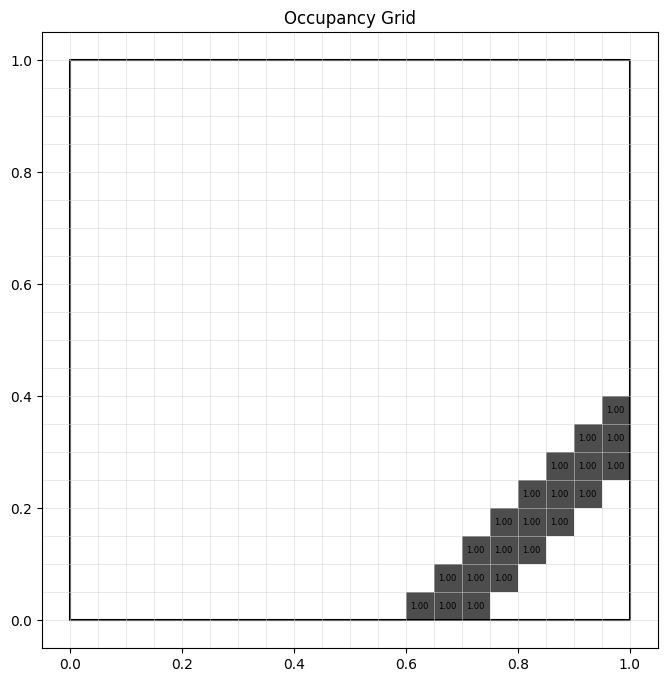

In [10]:
env.draw_grid_environment(env.initial_state['grid_mask'])
# stochastic_env.draw_grid_environment(stochastic_env.initial_state['grid_mask'])
# save grid to alphazero/data/
# np.save("../alphazero/data/simple_1_rect.npy", stochastic_env.initial_state['grid_mask'])
# np.save("../alphazero/data/deterministic/simple_1_rect_45.npy", env.initial_state['grid_mask'])

Push from [0.75 0.  ] to [0.75 1.  ]
New start idx: 35
Coverage after push: 0.000


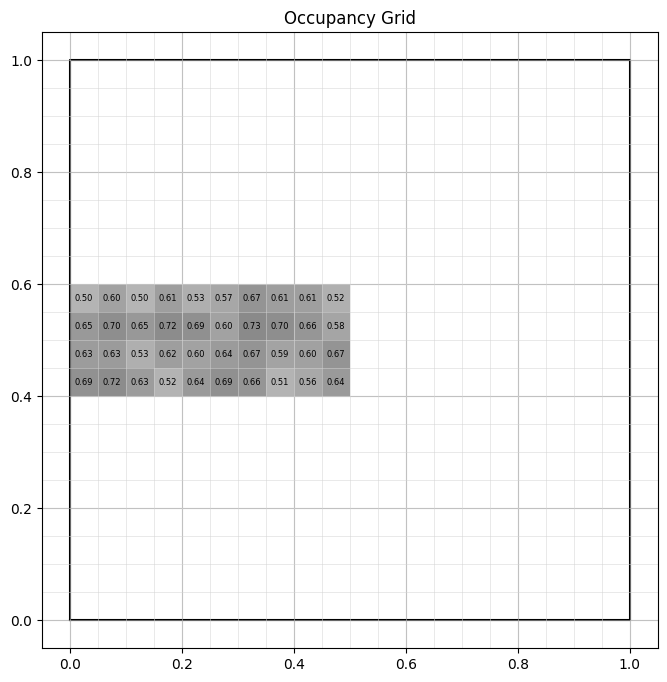

In [11]:

state, info = stochastic_env.reset()
push_env = stochastic_env.get_push_env()
action = 229
# action = 94
stochastic_env.animate_grid_push(action)

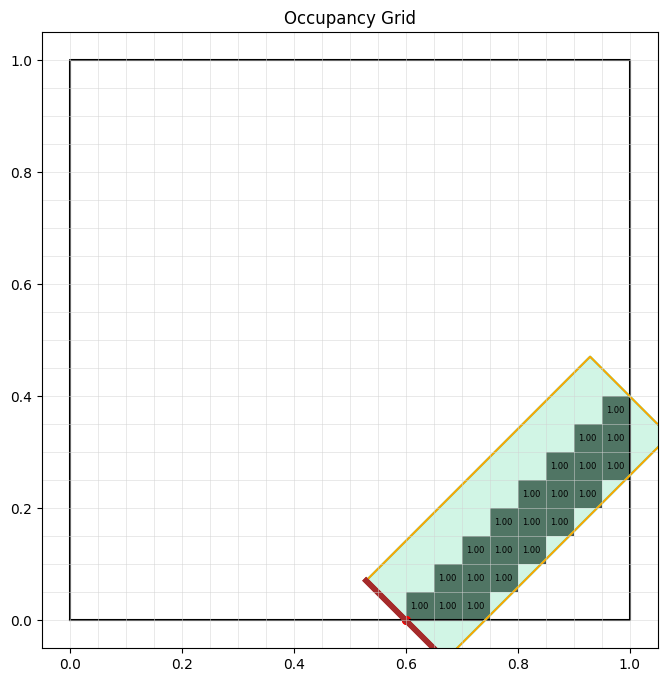

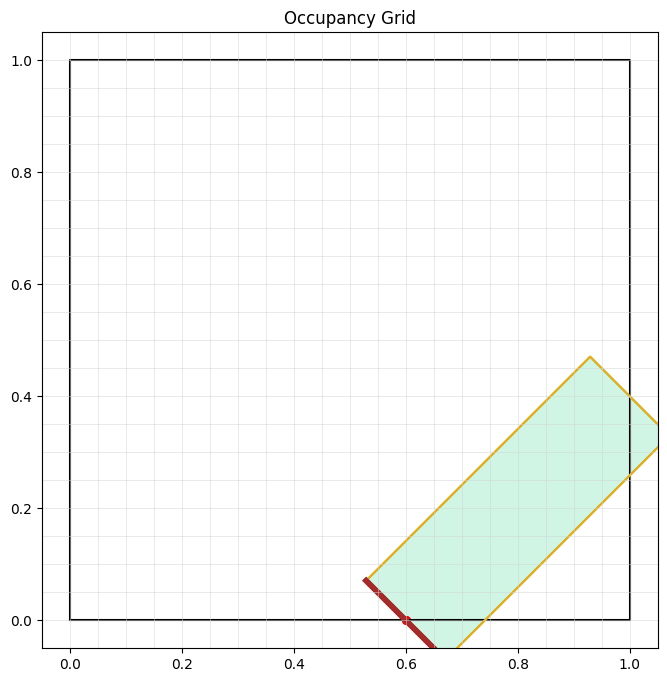

Done: True Truncated: False Reward: 9.368601755492886


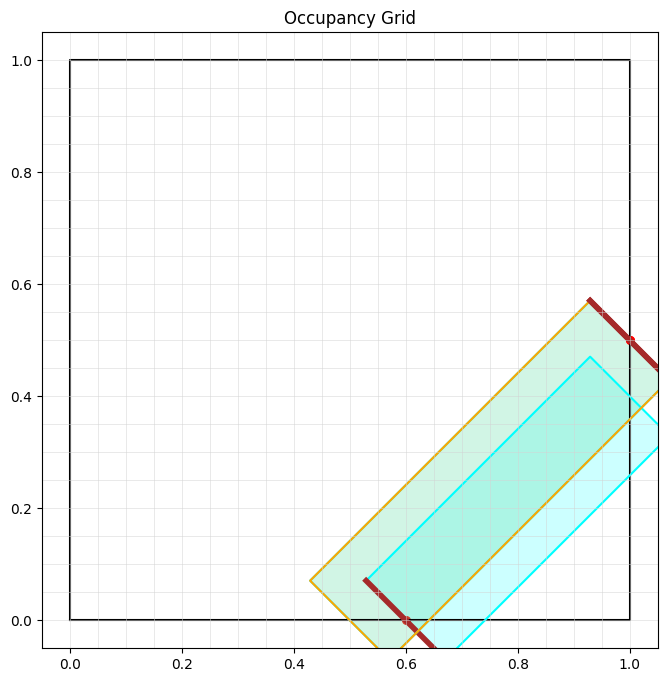

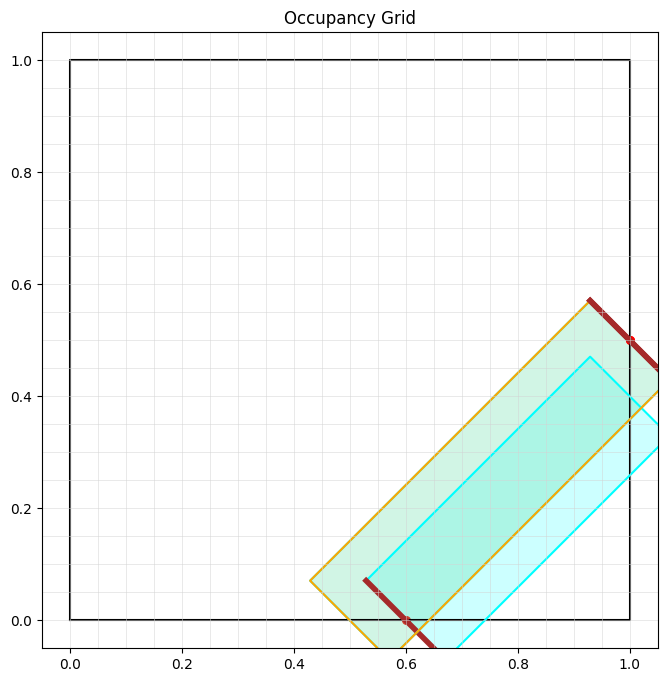

Done: True Truncated: False Reward: -0.5


In [11]:
pushes = []
state, info = env.reset()
push_env = env.get_push_env()

prev_state = state
s_before = prev_state['s_idx']
delta_s = -12
theta = np.pi/4
action = (delta_s, theta)

if isinstance(action, (int, np.integer)):
    delta_s, theta = push_env.action_space[action]
else:
    delta_s, theta = action

state, reward, done, truncated, info = env.step(action)

new_s_idx = (s_before + delta_s) % push_env.boundary_len
start_point = np.array(push_env.boundary_points[new_s_idx])
alpha = push_env.transform_theta_to_absolute(theta, start_point)
direction = np.array([np.cos(alpha), np.sin(alpha)])
pushes.append((start_point, direction))

env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
print("Done:", done, "Truncated:", truncated, "Reward:", reward)

prev_state = state
s_before = prev_state['s_idx']
action = (-2, -np.pi/4)

if isinstance(action, (int, np.integer)):
    delta_s, theta = push_env.action_space[action]
else:
    delta_s, theta = action

state, reward, done, truncated, info = env.step(action)

new_s_idx = (s_before + delta_s) % push_env.boundary_len
start_point = np.array(push_env.boundary_points[new_s_idx])
alpha = push_env.transform_theta_to_absolute(theta, start_point)
direction = np.array([np.cos(alpha), np.sin(alpha)])
pushes.append((start_point, direction))

env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
print("Done:", done, "Truncated:", truncated, "Reward:", reward)


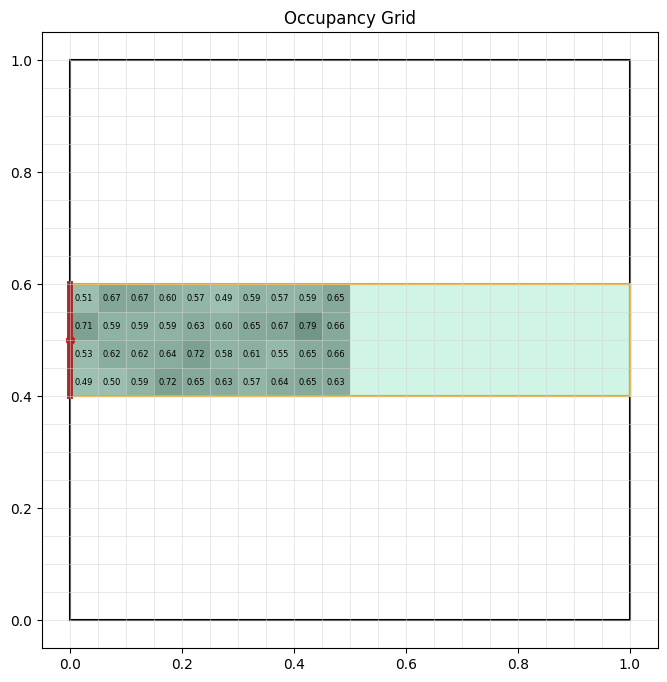

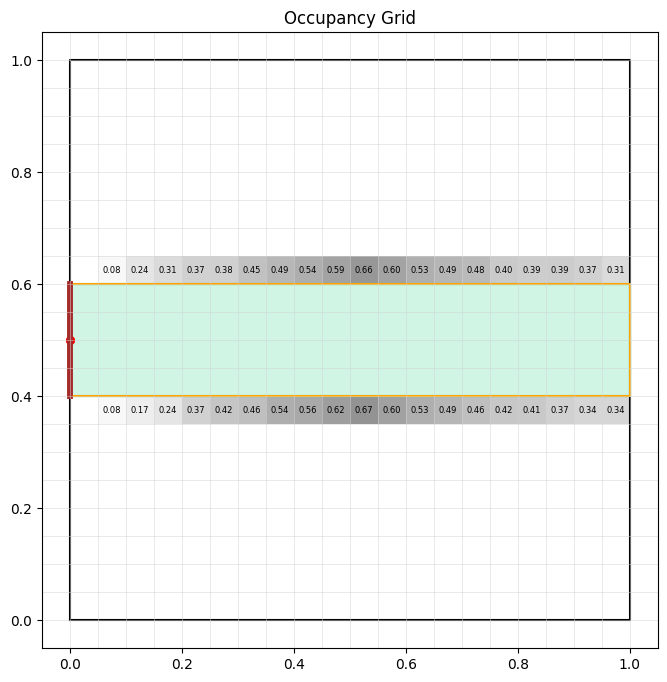

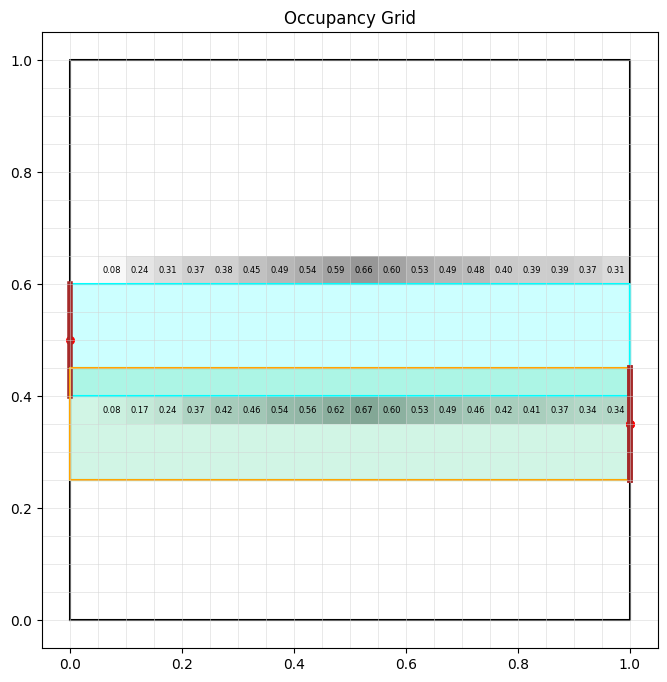

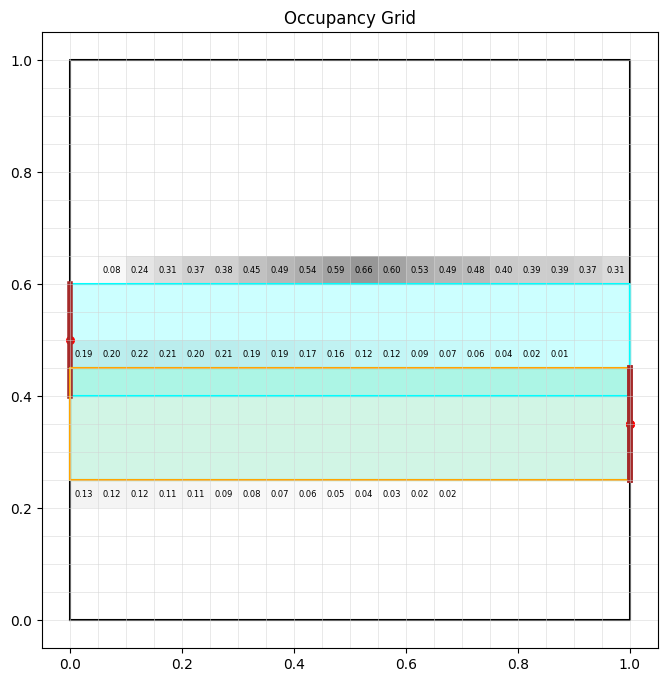

In [ ]:
pushes = []
state, info = stochastic_env.reset()
push_env = stochastic_env.get_push_env()

prev_state = state
s_before = prev_state['s_idx']
# action = 103
action = 229
# action = 238
# action = 49

if isinstance(action, (int, np.integer)):
    delta_s, theta = push_env.action_space[action]
else:
    delta_s, theta = action

state, reward, done, truncated, info = stochastic_env.step(action)

new_s_idx = (s_before + delta_s) % push_env.boundary_len
start_point = np.array(push_env.boundary_points[new_s_idx])
alpha = push_env.transform_theta_to_absolute(theta, start_point)
direction = np.array([np.cos(alpha), np.sin(alpha)])
pushes.append((start_point, direction))

stochastic_env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
stochastic_env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))

prev_state = state
s_before = prev_state['s_idx']
action = (3, np.pi/2)

if isinstance(action, (int, np.integer)):
    delta_s, theta = push_env.action_space[action]
else:
    delta_s, theta = action

state, reward, done, truncated, info = stochastic_env.step(action)

new_s_idx = (s_before + delta_s) % push_env.boundary_len
start_point = np.array(push_env.boundary_points[new_s_idx])
alpha = push_env.transform_theta_to_absolute(theta, start_point)
direction = np.array([np.cos(alpha), np.sin(alpha)])
pushes.append((start_point, direction))

stochastic_env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
stochastic_env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))


In [14]:
stochastic_env.compute_coverage(state['grid_mask'])

0.5307126503969993

In [6]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1] / "algorithms" / "rl-agents"))
from rl_agents.agents.tree_search.mcts import MCTSAgent

# agent = MCTSAgent(env=env, config=dict(horizon=5, episodes=10000, gamma=0.8, max_depth=5, temperature=50, step_strategy="subtree"))
# agent = MCTSAgent(env=env, config=dict(horizon=5, episodes=10000, gamma=0.8, max_depth=5, temperature=50))
# agent = MCTSAgent(env=stochastic_env, config=dict(horizon=3, episodes=10000, gamma=0.8, max_depth=5, temperature=50))
# agent = MCTSAgent(env=env, config=dict(horizon=3, episodes=10000, gamma=0.8, max_depth=5, temperature=50))
agent = MCTSAgent(env=env, config=dict(horizon=3, episodes=200, gamma=0.8, max_depth=5, temperature=50))
# agent = MCTSAgent(env=stochastic_env, config=dict(horizon=5, episodes=10000, gamma=0.8, max_depth=5, temperature=50))
# agent = MCTSAgent(env=env, config=dict(horizon=5, episodes=10000, gamma=0.8, max_depth=5, temperature=50))
# agent = MCTSAgent(env=env, config=dict(horizon=5, episodes=10000, gamma=0.99, max_depth=5, temperature=50))


In [ ]:
from rl_agents.agents.tree_search.mcts_dpw import MCTSDPWAgent

# agent = MCTSDPWAgent(env=stochastic_env, config=dict(horizon=3, episodes=10000, gamma=0.8, temperature=50, closed_loop=True, k_state=2, alpha_state=0.3, k_action=3, alpha_action=0.3))
# agent = MCTSDPWAgent(env=env, config=dict(horizon=5, episodes=10000, gamma=0.8, max_depth=5, temperature=20, k_action=10, alpha_action=0.5, step_strategy="subtree"))
# agent = MCTSDPWAgent(env=env, config=dict(horizon=5, episodes=10000, gamma=0.8, max_depth=5, temperature=5, k_action=10, alpha_action=0.3))

## Offline Planning

number of actions=720
Initial state:
Start idx=0
Starting MCTS planning...
episodes: 10000, horizon: 3, budget
temperature: 50, gamma: 0.8


selection_rule counts=[8, 9, 10, 10, 7, 15, 7, 25, 7, 24, 10, 26, 9, 10, 9, 10, 9, 8, 10, 9, 14, 8, 9, 8, 9, 42, 7, 9, 9, 10, 6453, 9, 9, 8, 7, 42, 9, 10, 9, 8, 18, 8, 8, 9, 10, 9, 7, 12, 9, 9, 19, 9, 44, 8, 60, 8, 20, 9, 13, 8, 9, 11, 9, 11, 9, 10, 13, 9, 9, 16, 9, 8, 20, 9, 9, 19, 10, 10, 17, 10, 19, 10, 17, 8, 8, 10, 10, 16, 8, 9, 10, 10, 12, 9, 8, 12, 10, 13, 9, 9, 15, 10, 12, 8, 8, 16, 11, 9, 9, 9, 15, 11, 8, 8, 10, 15, 10, 9, 9, 11, 15, 10, 9, 10, 10, 15, 8, 8, 9, 12, 20, 8, 10, 12, 15, 9, 12, 12, 9, 13, 12, 8, 15, 11, 10, 14, 10, 9, 14, 13, 9, 15, 11, 8, 11, 15, 12, 9, 10, 10, 9, 15, 13, 10, 11, 10, 8, 15, 10, 15, 11, 9, 12, 12, 10, 10, 18, 9, 13, 12, 11, 10, 10, 11, 8, 27, 9, 11, 12, 13, 11, 12, 11, 8, 17, 9, 12, 10, 12, 13, 11, 12, 8, 12, 9, 10, 9, 11, 11, 12, 13, 9, 10, 8, 10, 11, 11, 11, 13, 10, 11, 13, 10, 16, 9, 10, 11, 9, 12, 8, 11, 11, 9, 11, 9, 9, 10, 9, 11, 8, 11, 10, 10, 11, 9, 10, 9, 9, 9, 8, 10, 11, 9, 9, 8, 14, 10, 7, 8, 11, 12, 9, 7, 9, 9, 10, 8, 8, 8, 10, 12, 7, 

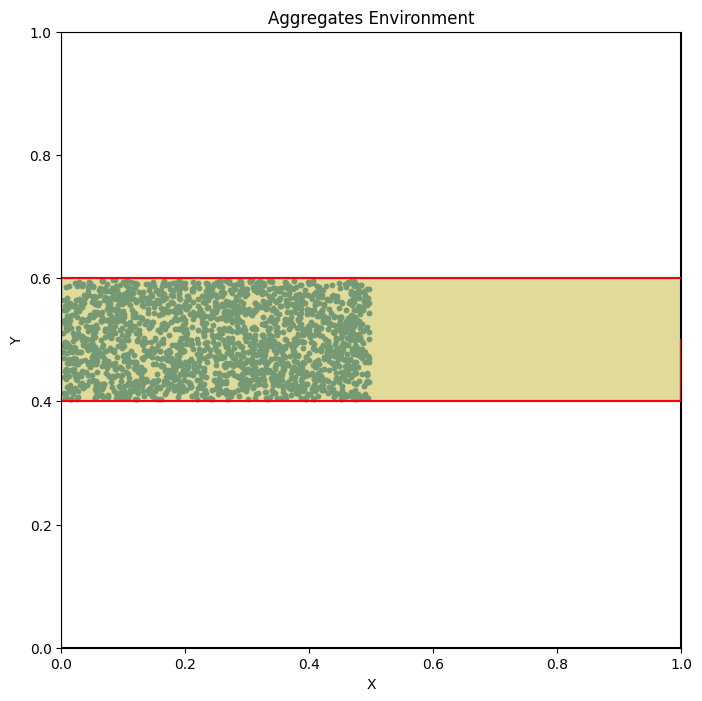

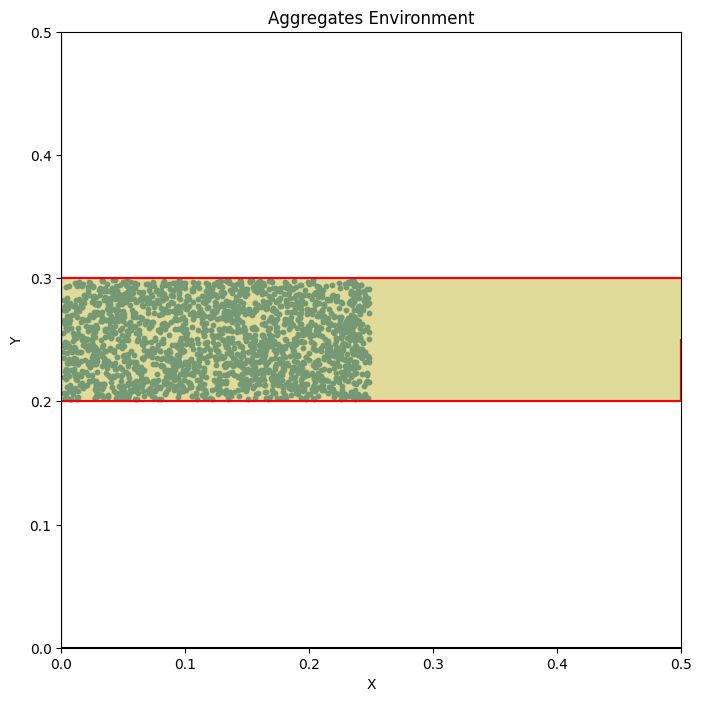

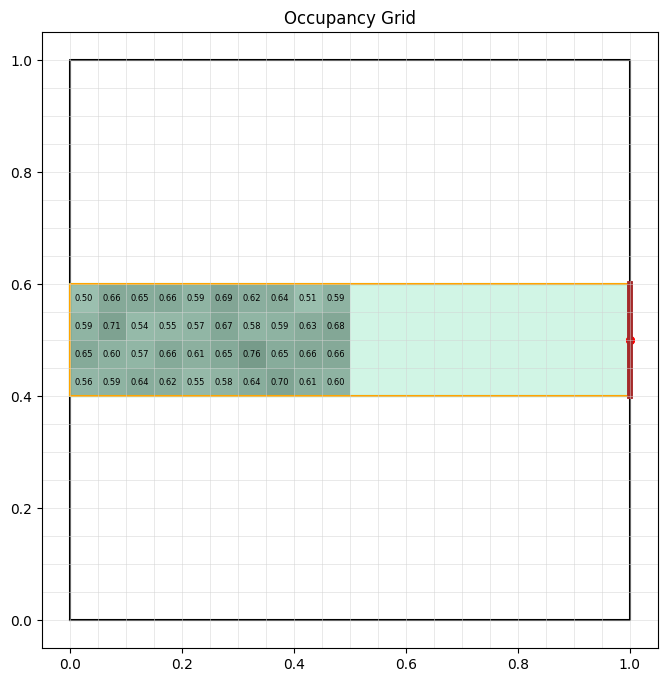

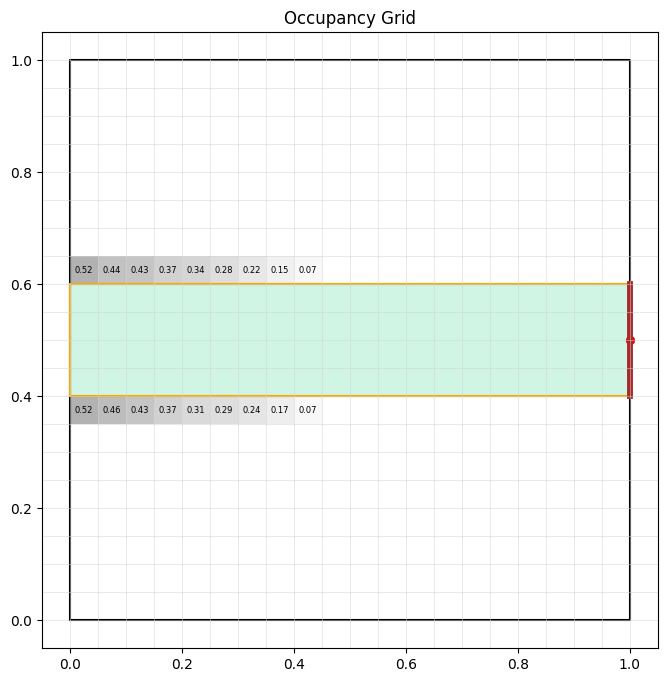

############ mcts action is 31
delta_s: -37, theta: 90.0 deg
############ state is {'s_idx': 7, 'grid_mask': array([[0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0492, 0.    , 0.    , 0.5176, 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0292, 0.    , 0.    , 0.4392, 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0256, 0.    , 0.    , 0.4288, 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0104, 0.    , 0.    , 0.3736, 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.3416, 0.    , 0.    , 0.    ,
       

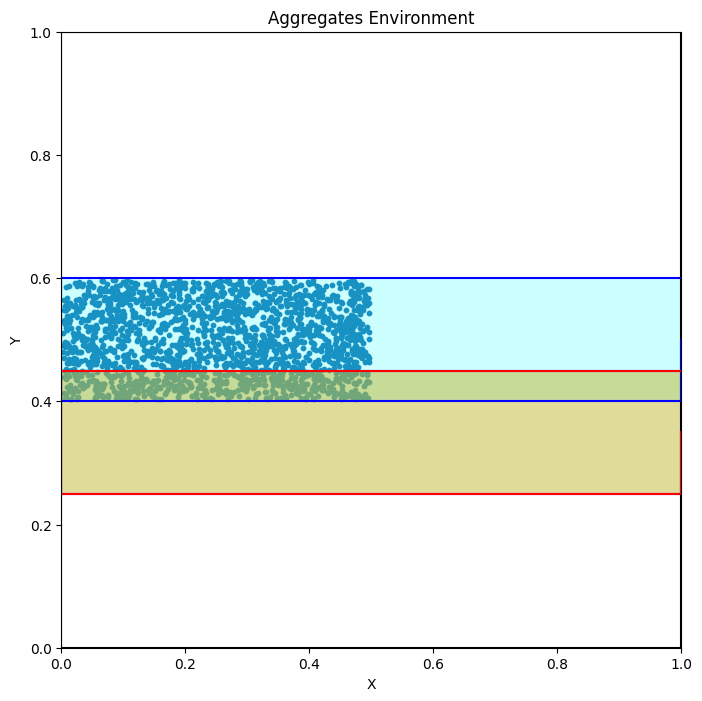

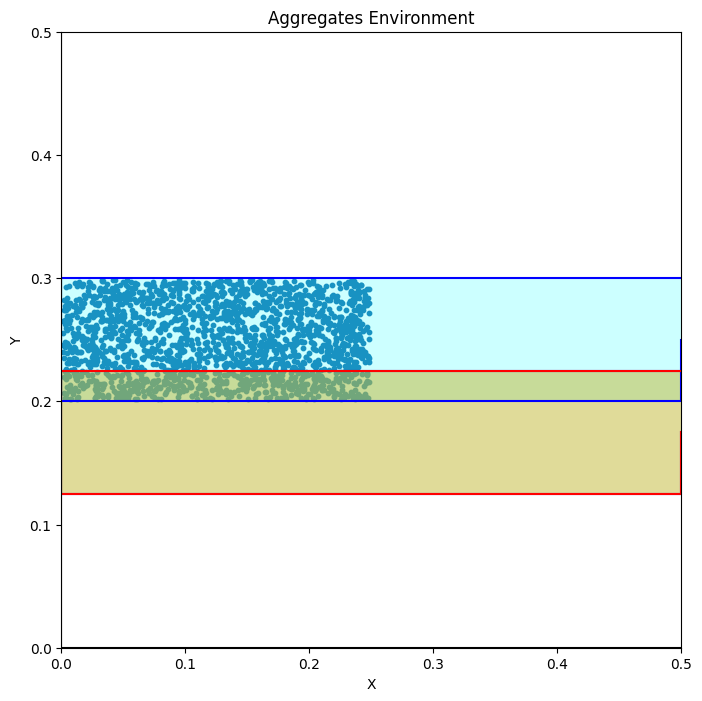

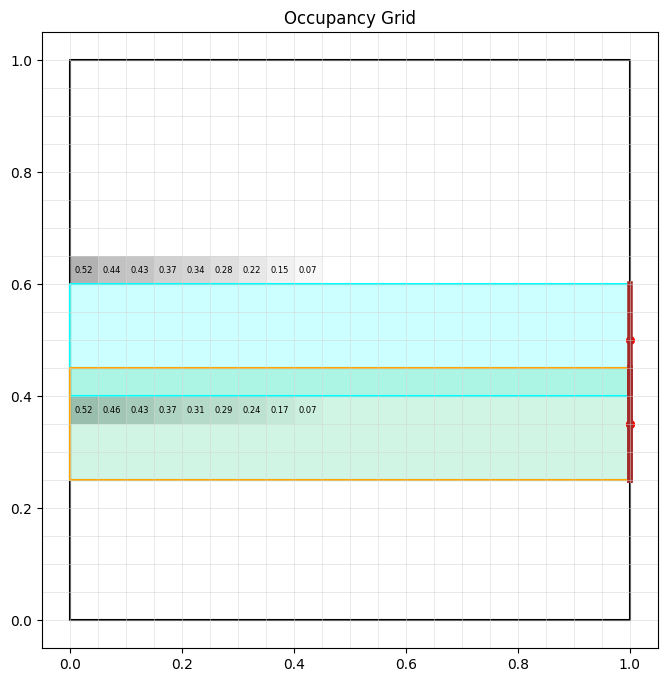

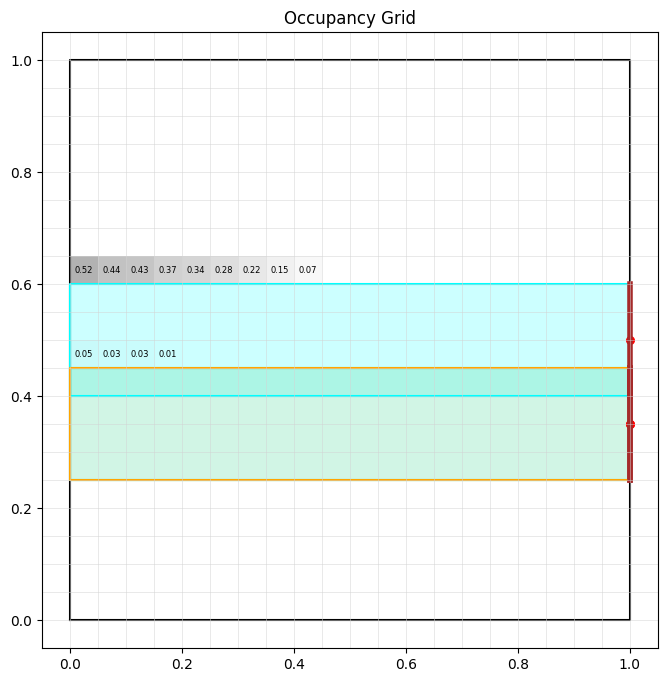

############ mcts action is 4
delta_s: -40, theta: 90.0 deg
############ state is {'s_idx': 13, 'grid_mask': array([[0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0492, 0.0432, 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0292, 0.0328, 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0256, 0.024 , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.0104, 0.0156, 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       

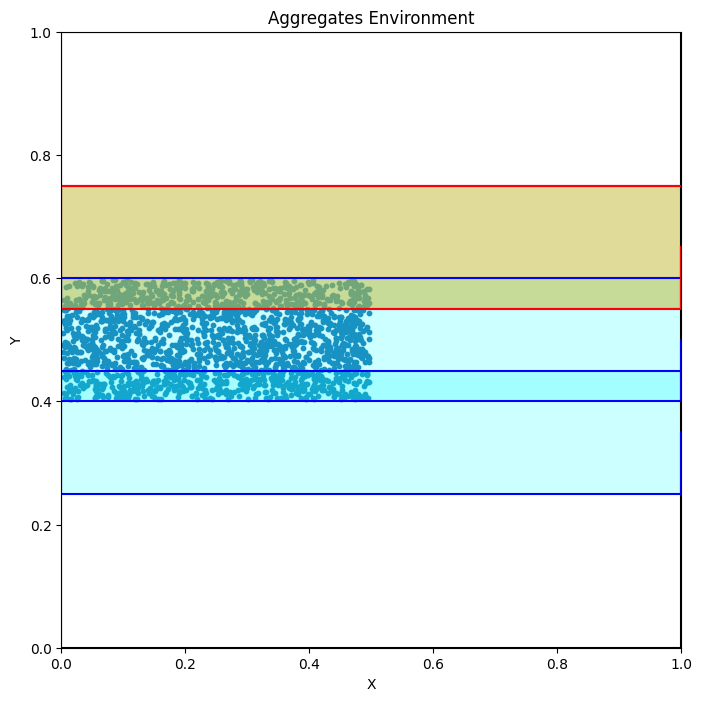

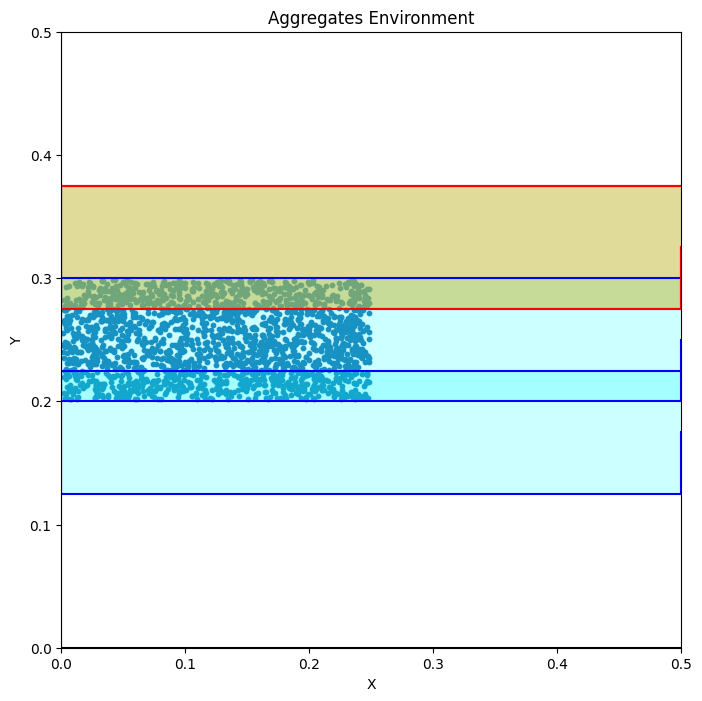

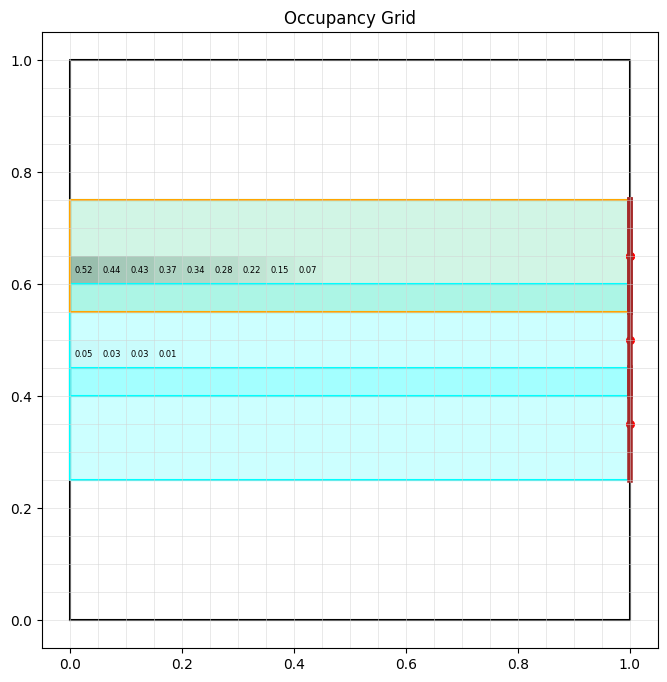

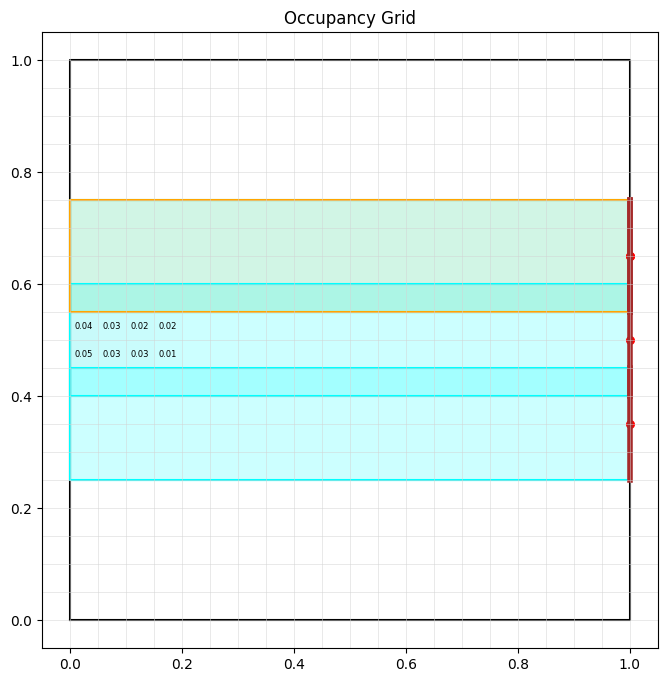

Coverage threshold reached: 99.07%
OR Reached the end of the environment or maximum pushes.
final_coverage: 0.9907219156420435 final_length: 167.0 final_reward: 2.3747091400802938
normed_length: 1.3928273561301083
cov/length ratio: 0.7113027406316229
total_reward: 2.9885109373498437


In [ ]:
# # Reset for main loop
# # sim_state, sim_info = env.reset()
# # state, info = stochastic_env.reset()
# state, info = env.reset()
# done = truncated = False
# total_reward = 0

# initial_state = env.initial_state.copy()
# current_state = state
# # push_env = stochastic_env.get_push_env()
# push_env = env.get_push_env()
# pushes = []
# normed_pushes = []
# global_pushes = []

# print("number of actions={}".format(len(push_env.action_space)))

# print("Initial state:")
# print(f"Start idx={s0}")
# print("Starting MCTS planning...")

# optimal_path = agent.act_offline(state)
# for step, action in enumerate(optimal_path):
#     # MCTS planning to find best action
#     # action = agent.act(sim_state)
#     print("############ mcts action is", action)
    
#     # Convert action index back to delta_s, theta
#     # The action_space in the new environment maps indices to (delta_s, theta) pairs
#     if isinstance(action, (int, np.integer)):
#         delta_s, theta = push_env.action_space[action]
#     else:
#         delta_s, theta = action
#     # delta_s, theta = push_env.action_space[action]
#     print(f"delta_s: {delta_s}, theta: {np.degrees(theta):.1f} deg")
    
#     prev_state = state
#     s_before = prev_state['s_idx']

#     # Take the action in the environment
#     # sim_state, sim_reward, sim_done, sim_truncated, sim_info = env.step(action)
#     state, reward, done, truncated, info = env.step(action)

#     print("############ state is", state)
#     print("############ reward is", reward)
#     # print("############ sim_reward is", sim_reward)
#     print("############ done", done)

#     total_reward += reward
    
#     push_len = info.get('t_max', 0)
#     print("push_len", push_len)
    
#     if delta_s is not None and theta is not None:
#         print(f"Push {step+1}: Start idx={s_before}, delta_s={delta_s}, theta={np.degrees(theta):.1f} deg, reward={reward:.4f}")
#         print("length", state['length'])
#         # pushes.append((s_before, delta_s, theta))

#     uncovered = np.count_nonzero(state['grid_mask'])
#     # coverage = env.compute_coverage(state['grid_mask'])
#     coverage = env.compute_coverage(state['grid_mask'])
#     print(f"coverage: {coverage} \n")

#     start_point, end_point, alpha = push_env.transform_push_to_normed_world(s_before, delta_s, theta)
#     print(f"Normed start_point: {start_point}, Normed end_point: {end_point}, Normed alpha: {alpha}")
 
#     start_point_global, end_point_global, alpha_global = push_env.transform_push_to_global_world(s_before, delta_s, theta)
#     print(f"Global start_point: {start_point_global}, Global end_point: {end_point_global}, Global alpha: {alpha_global}")
#     direction = np.array([np.cos(alpha), np.sin(alpha)])

#     pushes.append((start_point, direction))
#     normed_pushes.append((start_point, end_point, alpha))
#     global_pushes.append((start_point_global, end_point_global, alpha_global))

#     env.draw_environment(particles, pushes=normed_pushes, current_push=(start_point, end_point, alpha))
#     # env.draw_environment(particles, pushes=global_pushes, current_push=(start_point_global, end_point_global, alpha_global))
#     env.draw_real_environment(particles, pushes=global_pushes, current_push=(start_point_global, end_point_global, alpha_global))
#     # env.draw_grid_environment(env.initial_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
#     # env.draw_grid_environment(env.initial_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
#     env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
#     # env.draw_grid_environment(sim_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
#     env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
#     # env.draw_environment(particles, pushes=pushes, current_push=(s_before, delta_s, theta))
#     # env.draw_grid_environment(env.initial_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
#     # env.draw_grid_environment(sim_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
#     # env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))

#     # if done or sim_done:
#     if done:
#     # if done or coverage >= env.coverage_thresh:
#         print(f"Coverage threshold reached: {coverage*100:.2f}%")
#         print("OR Reached the end of the environment or maximum pushes.")
#         print("final_coverage:", env.compute_coverage(state['grid_mask']), "final_length:", state['length'], "final_reward:", reward)
#         # print("final_coverage:", env.compute_coverage(state['grid_mask']), "final_length:", state['length'], "final_reward:", reward)
#         max_total_length = ((grid_size * (1 / shovel_width)) + grid_size - shovel_width * 0.5)
#         normed_length = state['length'] / max_total_length
#         print("normed_length:", normed_length)
#         print("cov/length ratio:", coverage / normed_length)
#         print("total_reward:", total_reward)
#         break


## Online Planning

number of actions=720
Initial state:
Start idx=0
Starting MCTS planning...
episodes: 200, horizon: 3, budget
temperature: 50, gamma: 0.8
selection_rule counts=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 108, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
selection_rule actions len=79
max counts=108
selection_rule counts argmax=[44]
selected action value=4.2786774522428646
############ mcts action is 114
delta_s: -28, theta: 135.0 deg
############ state is {'s_idx': 68, 'grid_mask': array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False],
       [False, False, False, False, Fal

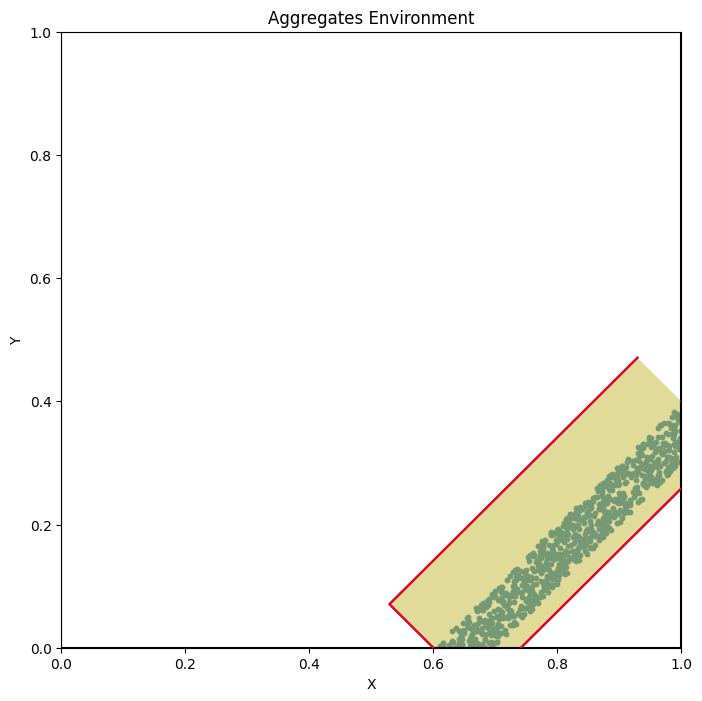

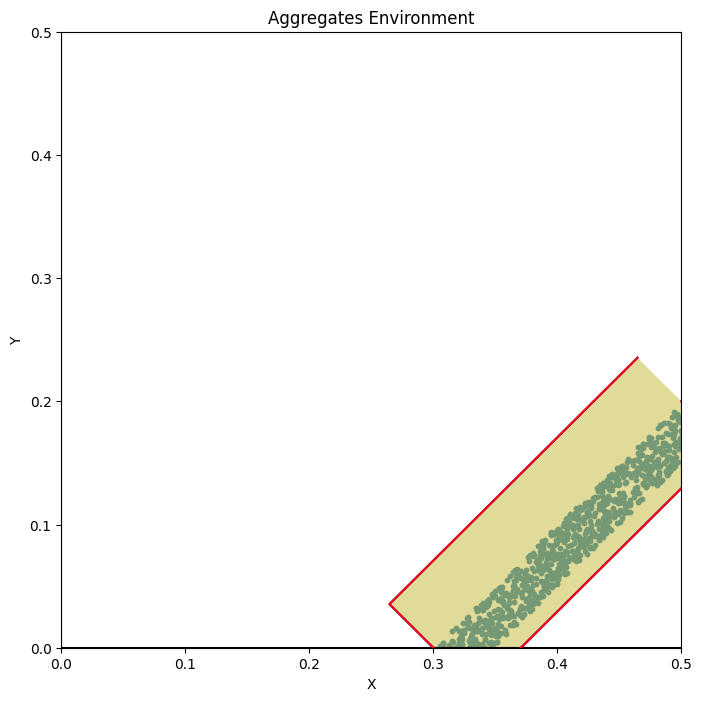

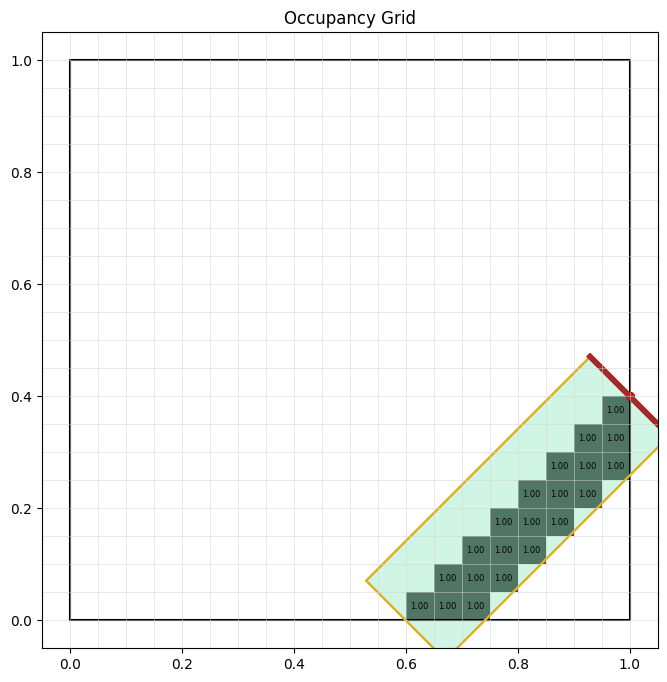

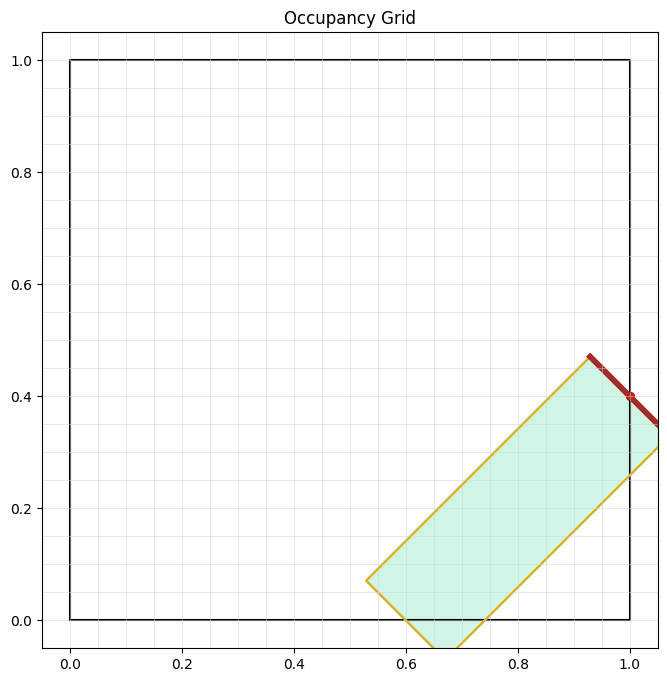

Coverage threshold reached: 100.00%
OR Reached the end of the environment or maximum pushes.
final_coverage: 1.0 final_length: 39.31370849898476 final_reward: 4.2786774522428646
normed_length: 0.3278874770557528
cov/length ratio: 3.049826754530072
total_reward: 4.2786774522428646


In [7]:
# Reset for main loop
# sim_state, sim_info = env.reset()
# state, info = stochastic_env.reset()
state, info = env.reset()
done = truncated = False
total_reward = 0

# initial_state = stochastic_env.initial_state.copy()
initial_state = env.initial_state.copy()
current_state = state
# push_env = stochastic_env.get_push_env()
push_env = env.get_push_env()
pushes = []
normed_pushes = []
global_pushes = []

print("number of actions={}".format(len(push_env.action_space)))

print("Initial state:")
print(f"Start idx={s0}")
print("Starting MCTS planning...")

for step in range(max_pushes):
    # MCTS planning to find best action
    # action = agent.act(sim_state)
    action = agent.act(state)
    print("############ mcts action is", action)
    
    # Convert action index back to delta_s, theta
    # The action_space in the new environment maps indices to (delta_s, theta) pairs
    if isinstance(action, (int, np.integer)):
        delta_s, theta = push_env.action_space[action]
    else:
        delta_s, theta = action
    # delta_s, theta = push_env.action_space[action]
    print(f"delta_s: {delta_s}, theta: {np.degrees(theta):.1f} deg")
    
    prev_state = state
    s_before = prev_state['s_idx']

    # Take the action in the environment
    # sim_state, sim_reward, sim_done, sim_truncated, sim_info = env.step(action)
    # state, reward, done, truncated, info = stochastic_env.step(action)
    state, reward, done, truncated, info = env.step(action)

    print("############ state is", state)
    print("############ reward is", reward)
    # print("############ sim_reward is", sim_reward)
    print("############ done", done)

    total_reward += reward
    
    push_len = info.get('t_max', 0)
    print("push_len", push_len)
    
    if delta_s is not None and theta is not None:
        print(f"Push {step+1}: Start idx={s_before}, delta_s={delta_s}, theta={np.degrees(theta):.1f} deg, reward={reward:.4f}")
        print("length", state['length'])
        # pushes.append((s_before, delta_s, theta))

    uncovered = np.count_nonzero(state['grid_mask'])
    coverage = env.compute_coverage(state['grid_mask'])
    # coverage = stochastic_env.compute_coverage(state['grid_mask'])
    print(f"coverage: {coverage} \n")

    start_point, end_point, alpha = push_env.transform_push_to_normed_world(s_before, delta_s, theta)
    print(f"Normed start_point: {start_point}, Normed end_point: {end_point}, Normed alpha: {alpha}")
 
    start_point_global, end_point_global, alpha_global = push_env.transform_push_to_global_world(s_before, delta_s, theta)
    print(f"Global start_point: {start_point_global}, Global end_point: {end_point_global}, Global alpha: {alpha_global}")
    direction = np.array([np.cos(alpha), np.sin(alpha)])

    pushes.append((start_point, direction))
    normed_pushes.append((start_point, end_point, alpha))
    global_pushes.append((start_point_global, end_point_global, alpha_global))

    # stochastic_env.draw_environment(particles, pushes=normed_pushes, current_push=(start_point, end_point, alpha))
    env.draw_environment(particles, pushes=normed_pushes, current_push=(start_point, end_point, alpha))
    # stochastic_env.draw_environment(particles, pushes=global_pushes, current_push=(start_point_global, end_point_global, alpha_global))
    # stochastic_env.draw_real_environment(particles, pushes=global_pushes, current_push=(start_point_global, end_point_global, alpha_global))
    env.draw_real_environment(particles, pushes=global_pushes, current_push=(start_point_global, end_point_global, alpha_global))
    # stochastic_env.draw_grid_environment(env.initial_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
    # stochastic_env.draw_grid_environment(stochastic_env.initial_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
    # stochastic_env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
    env.draw_grid_environment(prev_state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
    # stochastic_env.draw_grid_environment(sim_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
    # stochastic_env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
    env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(start_point, direction))
    # env.draw_environment(particles, pushes=pushes, current_push=(s_before, delta_s, theta))
    # env.draw_grid_environment(env.initial_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
    # env.draw_grid_environment(sim_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
    # env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))

    # if done or sim_done:
    if done:
    # if done or coverage >= env.coverage_thresh:
        print(f"Coverage threshold reached: {coverage*100:.2f}%")
        print("OR Reached the end of the environment or maximum pushes.")
        # print("final_coverage:", stochastic_env.compute_coverage(state['grid_mask']), "final_length:", state['length'], "final_reward:", reward)
        print("final_coverage:", env.compute_coverage(state['grid_mask']), "final_length:", state['length'], "final_reward:", reward)
        max_total_length = ((grid_size * (1 / shovel_width)) + grid_size - shovel_width * 0.5)
        normed_length = state['length'] / max_total_length
        print("normed_length:", normed_length)
        print("cov/length ratio:", coverage / normed_length)
        print("total_reward:", total_reward)
        break


In [ ]:
# sim_coverage = env.compute_coverage(sim_state['grid_mask'])
# print("sim_coverage:", sim_coverage)

## Main Loop

In [ ]:
# # Reset for main loop
# state = env.reset()
# uncovered = np.count_nonzero(state['grid_mask'])
# initial_grid = env.occupancy_grid.copy()
# initial_state = env.initial_state.copy()
# current_state = state
# pushes = []

# print("Initial state:")
# print(f"Start idx={s0}")
# print("Starting MCTS planning...")
# length = 0
# done = False
# total_reward = 0

# # Reset the MCTS game
# state, _ = game.reset()

# for step in range(max_pushes):
#     # MCTS planning to find best action
#     best_action = mcts_agent.step(game, state, total_reward, done)
#     print("############ mcts action is", best_action)
    
#     # Convert action index back to delta_s, theta
#     # The action_space in the new environment maps indices to (delta_s, theta) pairs
#     delta_s, theta = env.action_space[best_action]
    
#     s_before = state['s_idx']

#     # Take the action in the environment
#     # current_state, reward, done, info = env.step(best_action)

    
#     # Also step the game for MCTS
#     state, reward, done = game.step(best_action)
#     print("############ state is", state)
#     print("############ reward is", reward)
#     print("############ done", done)
#     print("############ children visit counts:", [child.visit_count for child in mcts_agent.result_node.children.values() if child.visit_count>0])
#     print("############ children visit counts:", mcts_agent.result_node.visit_count)
#     total_reward += reward
    
#     # push_len = info.get('t_max', 0)
#     # print("push_len", push_len)
    
#     if delta_s is not None and theta is not None:
#         print(f"Push {step+1}: Start idx={s_before}, delta_s={delta_s}, theta={np.degrees(theta):.1f} deg, reward={reward:.4f}")
#         # length += abs(delta_s) + push_len * float(grid_size)
#         print("length", state['length'])
#         pushes.append((s_before, delta_s, theta))

#     uncovered = np.count_nonzero(state['grid_mask'])
#     coverage = env.compute_coverage(state['grid_mask'])
#     print(f"coverage: {coverage} \n")

#     env.draw_environment(particles, pushes=pushes, current_push=(s_before, delta_s, theta))
#     env.draw_grid_environment(env.initial_state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))
#     # env.draw_grid_environment(current_state['grid_mask'])
#     env.draw_grid_environment(state['grid_mask'], pushes=pushes, current_push=(s_before, delta_s, theta))

#     if done:
#     # if done or coverage >= env.coverage_thresh:
#         print(f"Coverage threshold reached: {coverage*100:.2f}%")
#         print("OR Reached the end of the environment or maximum pushes.")
#         print("final_coverage:", env.compute_coverage(state['grid_mask']), "final_length:", state['length'], "final_reward:", reward)
#         max_total_length = ((grid_size * (1 / shovel_width)) + grid_size - shovel_width * 0.5)
#         normed_length = state['length'] / max_total_length
#         print("normed_length:", normed_length)
#         print("cov/length ratio:", coverage / normed_length)
#         print("cov/length ratio (unnormed):", coverage / normed_length)
#         break

#     game.close()  # Close the game to free resources

## Output Visualization


Final coverage: 76.92%


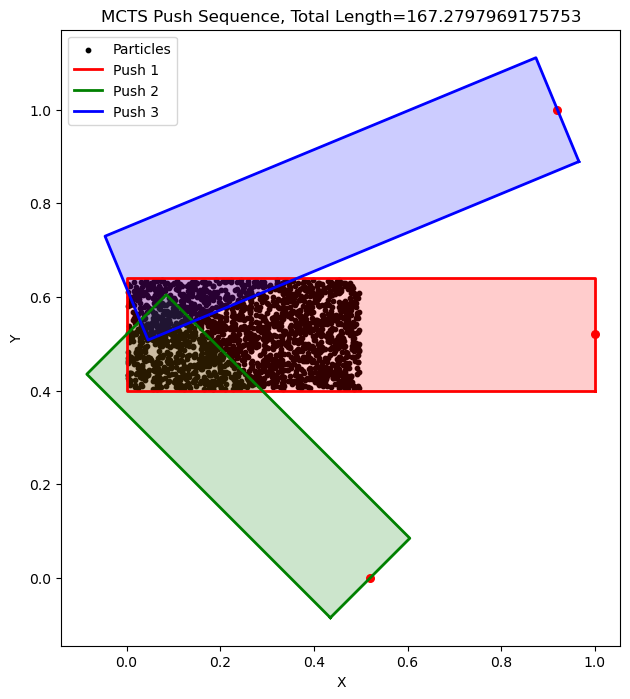

Executed pushes: [(array([1.  , 0.52]), array([-1.0000000e+00,  1.2246468e-16])), (array([0.52, 0.  ]), array([-0.70710678,  0.70710678])), (array([0.92, 1.  ]), array([-0.92387953, -0.38268343]))]


In [ ]:
final_coverage = env.compute_coverage(state['grid_mask'])
print(f"\nFinal coverage: {final_coverage*100:.2f}%")
env.plot_pushes_original_space(
                    pushes=normed_pushes,
                    boundary_points=boundary_points,
                    rock_positions=particles,
                    shovel_width=shovel_width,
                    title=f"MCTS Push Sequence, Total Length={state['length']}")

print("Executed pushes:", pushes)


Final coverage: 76.92%


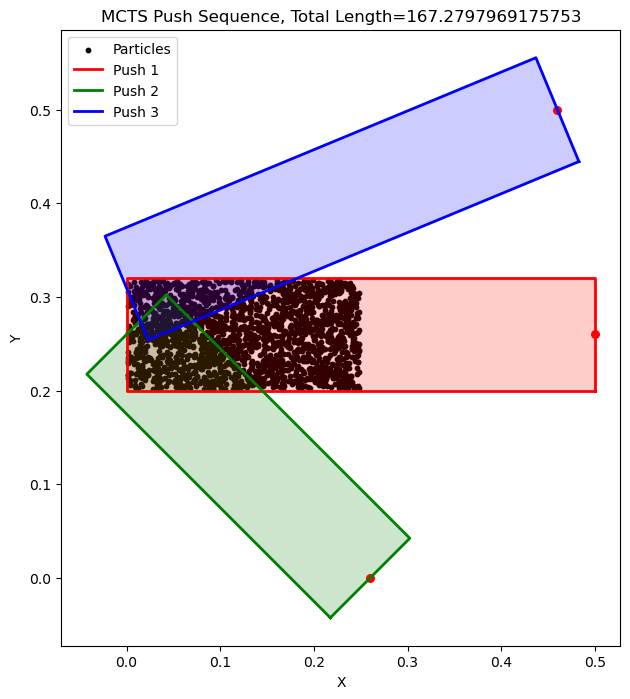

Executed pushes: [(array([1.  , 0.52]), array([-1.0000000e+00,  1.2246468e-16])), (array([0.52, 0.  ]), array([-0.70710678,  0.70710678])), (array([0.92, 1.  ]), array([-0.92387953, -0.38268343]))]


In [ ]:
final_coverage = env.compute_coverage(state['grid_mask'])
print(f"\nFinal coverage: {final_coverage*100:.2f}%")
env.plot_pushes_original_space(
                    pushes=global_pushes,
                    boundary_points=boundary_points,
                    rock_positions=particles * 0.5,  # Scale back to global world units
                    shovel_width=shovel_width * 0.5,  # Scale back to global world units
                    title=f"MCTS Push Sequence, Total Length={state['length']}")

print("Executed pushes:", pushes)

In [ ]:
# new_particles = env.grid_to_particles(current_state['grid_mask'])
# env.plot_pushes_original_space(
#                     pushes=pushes,  # list of (s_idx, delta_s, theta)
#                     boundary_points=boundary_points,
#                     rock_positions=new_particles,
#                     shovel_width=shovel_width,
#                     title=f"MCTS Push Sequence")

## Reward Function Analysis

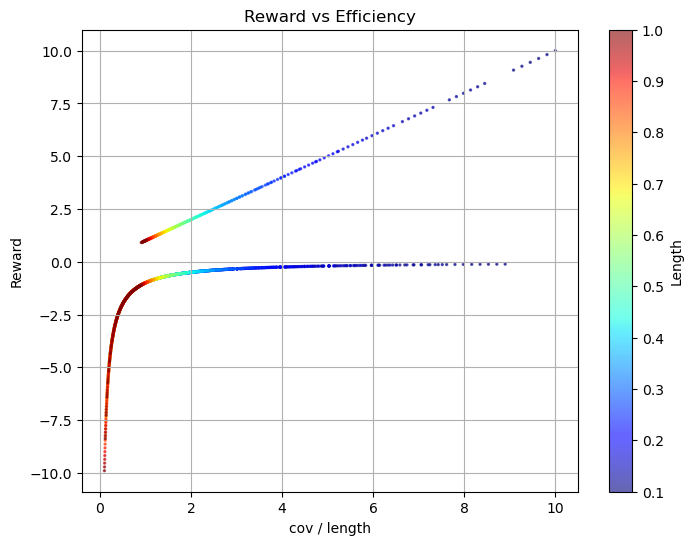

In [ ]:
# Constants
cov_thresh = 0.9
epsilon = 1e-3  # to avoid division by zero

# Create meshgrid of cov and length
cov = np.linspace(0.1, 1, 50)
length = np.linspace(0.1, 1, 50)
COV, LENGTH = np.meshgrid(cov, length)

# Compute x and y
# X = LENGTH   # efficiency
X = COV / LENGTH   # efficiency

Y = np.where(
    COV >= cov_thresh,
    # np.tanh(alpha * eff),
    X,
    -(1 / (X + epsilon))  # avoid division by zero
)


# Flatten to plot in 2D
x_vals = X.flatten()
y_vals = Y.flatten()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, c=LENGTH,cmap="jet", alpha=0.6, s=2)
plt.colorbar(label='Length')
# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.axvline(cov_thresh / 1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('cov / length')
plt.ylabel('Reward')
# plt.ylim(-1, 1)
plt.title('Reward vs Efficiency')
plt.grid(True)
plt.show()

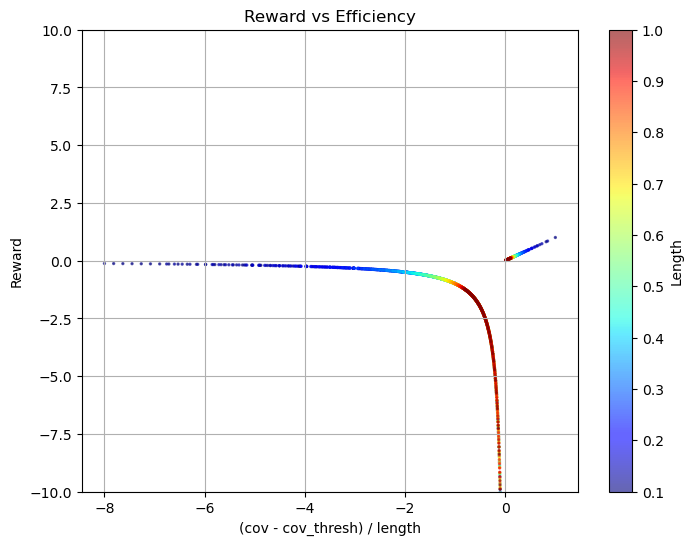

In [ ]:
# Constants
cov_thresh = 0.9
epsilon = 1e-3  # to avoid division by zero

# Create meshgrid of cov and length
cov = np.linspace(0.1, 1, 50)
length = np.linspace(0.1, 1, 50)
COV, LENGTH = np.meshgrid(cov, length)

# Compute x and y
# X = LENGTH   # efficiency
X = (COV - cov_thresh) / LENGTH   # efficiency
# Y = np.tanh(0.005*((COV - cov_thresh) / LENGTH))  # reward
Y = np.where(
    COV >= cov_thresh,
    # np.tanh(alpha * eff),
    X,
    ( 1 / (X + epsilon))  # avoid division by zero
)


# Flatten to plot in 2D
x_vals = X.flatten()
y_vals = Y.flatten()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, c=LENGTH,cmap="jet", alpha=0.6, s=2)
plt.colorbar(label='Length')
# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.axvline(cov_thresh / 1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('(cov - cov_thresh) / length')
plt.ylabel('Reward')
plt.ylim(-10, 10)
plt.title('Reward vs Efficiency')
plt.grid(True)
plt.show()

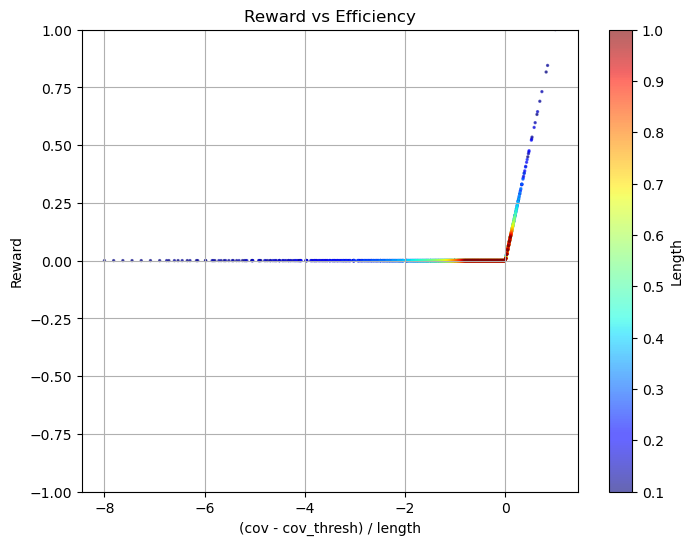

In [ ]:
# Constants
cov_thresh = 0.9
epsilon = 1e-3  # to avoid division by zero

# Create meshgrid of cov and length
cov = np.linspace(0.1, 1, 50)
length = np.linspace(0.1, 1, 50)
COV, LENGTH = np.meshgrid(cov, length)

# Compute x and y
# X = LENGTH   # efficiency
X = (COV - cov_thresh) / LENGTH   # efficiency
Y = np.where(
    COV >= cov_thresh,
    # np.tanh(alpha * eff),
    X,
    0  # avoid division by zero
)


# Flatten to plot in 2D
x_vals = X.flatten()
y_vals = Y.flatten()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, c=LENGTH,cmap="jet", alpha=0.6, s=2)
plt.colorbar(label='Length')
# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.axvline(cov_thresh / 1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('(cov - cov_thresh) / length')
plt.ylabel('Reward')
plt.ylim(-1, 1)
plt.title('Reward vs Efficiency')
plt.grid(True)
plt.show()

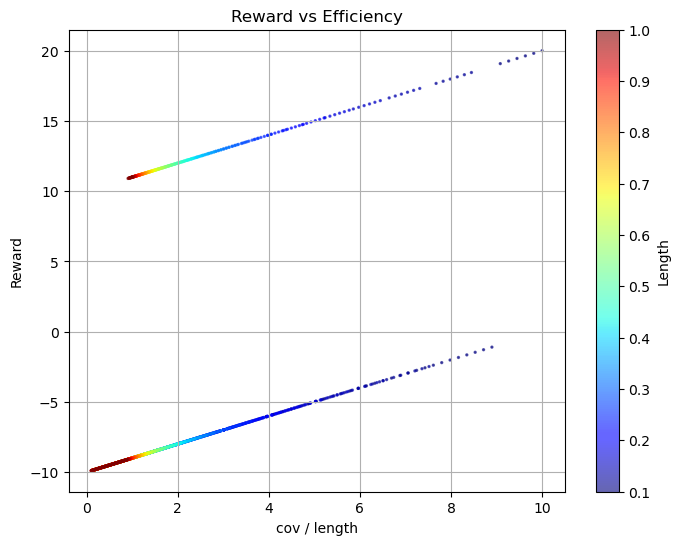

In [ ]:
# Constants
cov_thresh = 0.9
epsilon = 1e-3  # to avoid division by zero

# Create meshgrid of cov and length
cov = np.linspace(0.1, 1, 50)
length = np.linspace(0.1, 1, 50)
COV, LENGTH = np.meshgrid(cov, length)

# Compute x and y
# X = LENGTH   # efficiency
X = (COV) / LENGTH   # efficiency

Y = np.where(
    COV >= cov_thresh,
    # np.tanh(alpha * eff),
    X +10,
    X -10  # avoid division by zero
)


# Flatten to plot in 2D
x_vals = X.flatten()
y_vals = Y.flatten()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, c=LENGTH,cmap="jet", alpha=0.6, s=2)
plt.colorbar(label='Length')
# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.axvline(cov_thresh / 1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('cov / length')
plt.ylabel('Reward')
# plt.ylim(-1, 1)
plt.title('Reward vs Efficiency')
plt.grid(True)
plt.show()

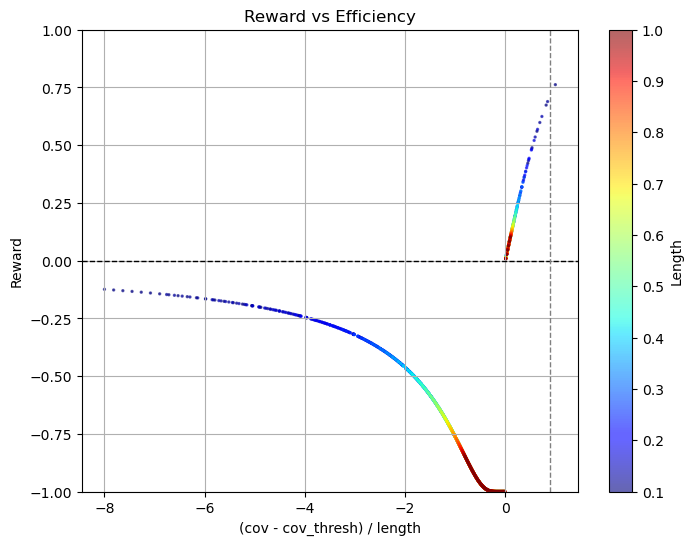

In [ ]:
# Constants
cov_thresh = 0.9
epsilon = 1e-3  # to avoid division by zero
alpha = 1.0  # controls sharpness of reward/penalty

# Create meshgrid of cov and length
cov = np.linspace(0.1, 1, 50)
length = np.linspace(0.1, 1, 50)
COV, LENGTH = np.meshgrid(cov, length)

# Compute x and y
# X = LENGTH   # efficiency
X = (COV - cov_thresh) / LENGTH   # efficiency
Y = np.tanh(0.005*((COV - cov_thresh) / LENGTH))  # reward
Y = np.where(
    COV >= cov_thresh,
    np.tanh(alpha * X),
    np.tanh(alpha *(1 / (X + epsilon)))  # avoid division by zero
)


# Flatten to plot in 2D
x_vals = X.flatten()
y_vals = Y.flatten()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, c=LENGTH,cmap="jet", alpha=0.6, s=2)
plt.colorbar(label='Length')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(cov_thresh / 1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('(cov - cov_thresh) / length')
plt.ylabel('Reward')
plt.ylim(-1, 1)
plt.title('Reward vs Efficiency')
plt.grid(True)
plt.show()

max inv_delta_length_normed: 0.0061975017735999335
max delta_length_normed: 0.5205901489823944
max delta_coverage_normed: 0.4834051383407948


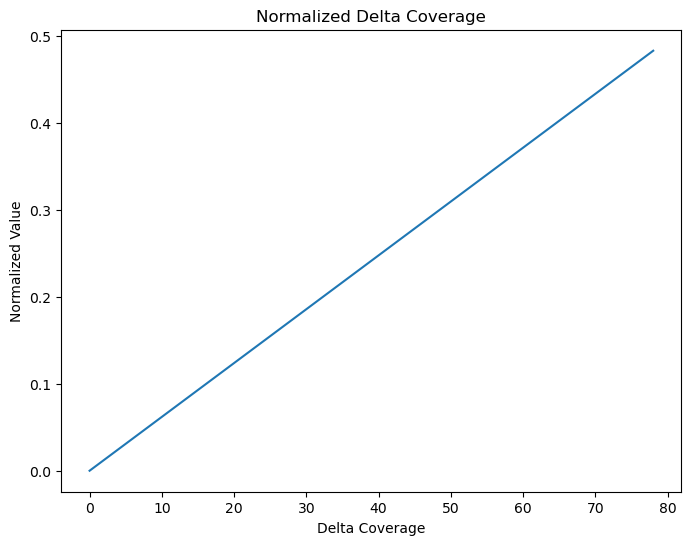

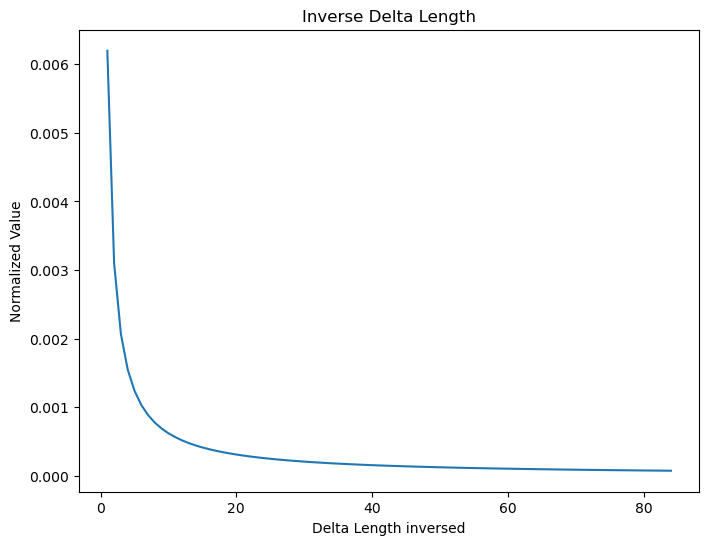

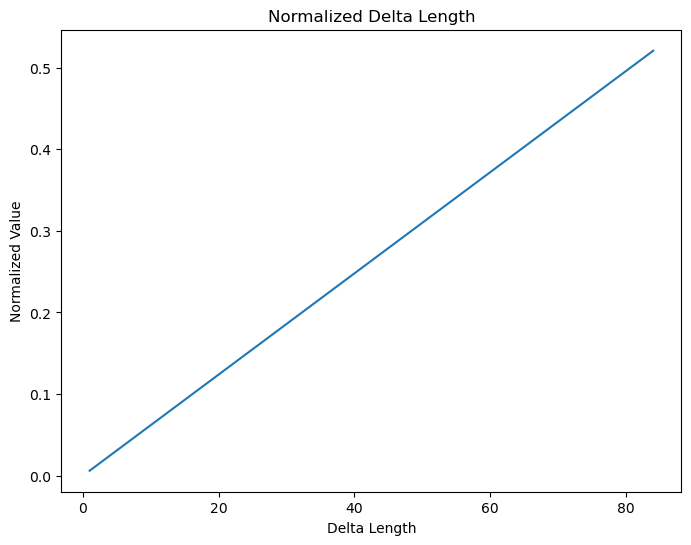

In [ ]:
max_length = np.sqrt(2) * grid_size + max(delta_s_options)

max_coverage = np.count_nonzero(env.initial_state['grid_mask'])
delta_length_vec = np.array([x for x in np.arange(0, max_length + 1) if x != 0.0], dtype=float)
inv_delta_length = 1.0 / (delta_length_vec)
delta_coverage_vec = np.arange(0, max_coverage + 1, dtype=float)
norm_term = max_length + max_coverage
inv_delta_length_normed = inv_delta_length / norm_term
delta_length_normed = delta_length_vec / norm_term
delta_coverage_normed = delta_coverage_vec / norm_term

print("max inv_delta_length_normed:", np.max(inv_delta_length_normed))
print("max delta_length_normed:", np.max(delta_length_normed))
print("max delta_coverage_normed:", np.max(delta_coverage_normed))

plt.figure(figsize=(8, 6))
plt.plot(delta_coverage_vec, delta_coverage_normed, label='Coverage (normalized)')
plt.xlabel('Delta Coverage')
plt.ylabel('Normalized Value')
plt.title('Normalized Delta Coverage')
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(delta_length_vec, inv_delta_length_normed, label='Inverse Length (normalized)')
plt.xlabel('Delta Length inversed')
plt.ylabel('Normalized Value')
plt.title('Inverse Delta Length')
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(delta_length_vec, delta_length_normed, label='Inverse Length (normalized)')
plt.xlabel('Delta Length')
plt.ylabel('Normalized Value')
plt.title('Normalized Delta Length')
plt.show()



# reward = (alpha * (delta_coverage / norm_term) + (1-alpha) * (inv_delta_length / norm_term)) * 100.0

epsilon: 4.167766952966369
max delta_length_normed: 1.0
max delta_length: 84.16776695296637
max max_length: 83.35533905932738
max delta_coverage_normed: 1.0


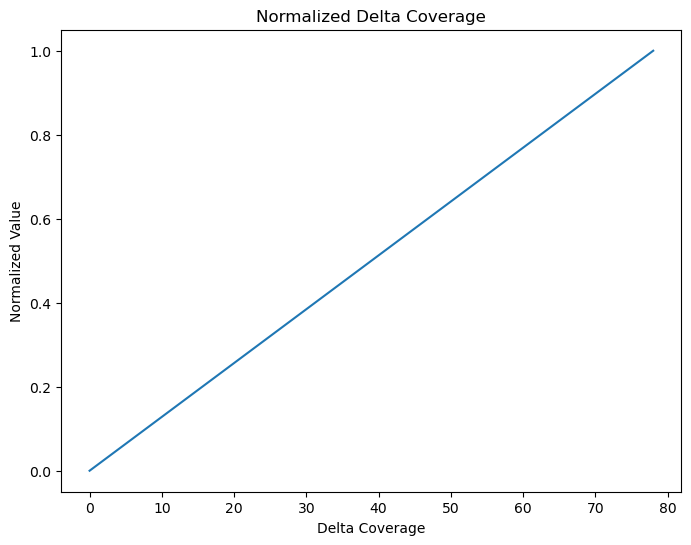

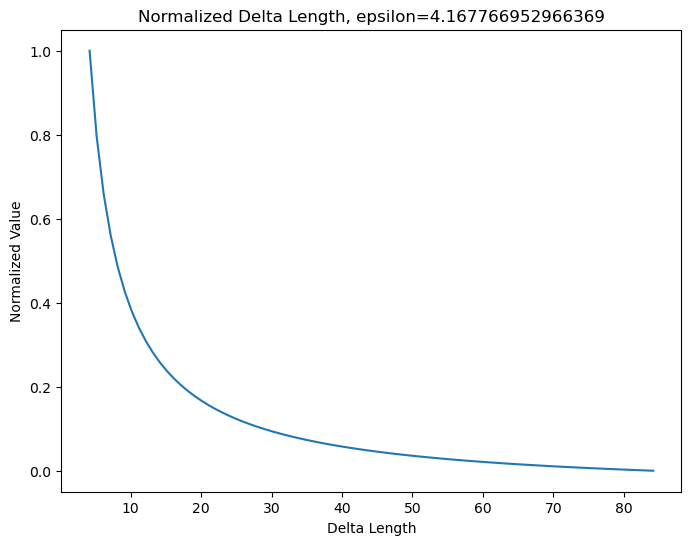

In [ ]:
epsilon = 0.05 * max_length 
# epsilon = 1.0
delta_length_vec = np.array([x for x in np.arange(epsilon, max_length + 1)], dtype=float)
delta_length_normed_new = (epsilon * (max_length - delta_length_vec)) / (delta_length_vec * (max_length - epsilon))
delta_coverage_normed_new = delta_coverage_vec / max_coverage

print("epsilon:", epsilon)
print("max delta_length_normed:", np.max(delta_length_normed_new))
print("max delta_length:", np.max(delta_length_vec))
print("max max_length:", max_length)
print("max delta_coverage_normed:", np.max(delta_coverage_normed_new))

plt.figure(figsize=(8, 6))
plt.plot(delta_coverage_vec, delta_coverage_normed_new, label='Coverage (normalized)')
plt.xlabel('Delta Coverage')
plt.ylabel('Normalized Value')
plt.title('Normalized Delta Coverage')
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(delta_length_vec, delta_length_normed_new, label='Length (normalized)')
plt.xlabel('Delta Length')
plt.ylabel('Normalized Value')
plt.title('Normalized Delta Length, epsilon={}'.format(epsilon))
plt.show()